In [4]:
import numpy as np
from scipy.linalg import logm, expm
from proxtoolbox.algorithms.metric import Prox
from proxtoolbox.spaces.spd import SymmetricPositiveDefinite

# ------------------------------------------------------------
# 0) Setup your space + prox (AIRM)
# ------------------------------------------------------------
space = SymmetricPositiveDefinite(dimension=3, metric="AIRM")
prox = Prox(space=space)

# ------------------------------------------------------------
# 1) DTI-like synthetic tensors (a tiny “fake MRI voxel ROI”)
#    In DTI, each voxel tensor is a 3x3 SPD matrix describing an ellipsoid.
#    Typical eigenvalues (mm^2/s) are on the order of 1e-3.
# ------------------------------------------------------------
def random_rotation(rng):
    """Random rotation matrix in SO(3) via QR; ensures det=+1."""
    A = rng.normal(size=(3, 3))
    Q, R = np.linalg.qr(A)
    # Fix sign to make det(Q)=+1
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q

def make_dti_tensor(rng, evals, log_noise_scale=0.05):
    """
    Create a DTI-like SPD tensor:
      D = R * exp( log(diag(evals)) + symmetric_noise ) * R^T
    Noise is injected in the log-domain so SPD is guaranteed.
    """
    R = random_rotation(rng)
    D0 = np.diag(evals)

    # symmetric noise in log-domain
    E = rng.normal(scale=log_noise_scale, size=(3, 3))
    E = 0.5 * (E + E.T)

    D = R @ expm(logm(D0) + E) @ R.T
    return space._project_to(D)  # extra safety

def fractional_anisotropy(D):
    """FA from eigenvalues (common DTI scalar map)."""
    w = np.linalg.eigvalsh(0.5 * (D + D.T))
    w = np.maximum(w, 1e-30)
    md = np.mean(w)
    num = 1.5 * np.sum((w - md) ** 2)
    den = np.sum(w ** 2)
    return float(np.sqrt(num / den)) if den > 0 else 0.0

# Ground-truth-ish white matter eigenvalues (mm^2/s, rough typical scale)
# (axial ~ 1.5–2.0e-3, radial ~ 0.2–0.6e-3)
evals_white_matter = np.array([1.7e-3, 0.4e-3, 0.3e-3], dtype=np.float64)

rng = np.random.default_rng(0)
S = [make_dti_tensor(rng, evals_white_matter, log_noise_scale=0.08) for _ in range(20)]

# ------------------------------------------------------------
# 2) Compute Fréchet mean using YOUR algorithm (prox-based cyclic/relaxed)
# ------------------------------------------------------------
x0 = S[0]  # initial guess
mu, traj = prox.Frechet_mean(
    x0=x0,
    X=S,
    method="relaxed",   # IMPORTANT: your code always passes (tau, lam),
                        # so "relaxed" is the safe option
    tau=0.7,            # relaxation along geodesic toward prox point
    lam=1.0,            # proximal parameter for distance term
    tol=1e-14,
    max_iter=200,
    show_progress=True
)

print("\nMean computed.")
print("Mean eigenvalues:", np.linalg.eigvalsh(mu))
print("Mean FA:", fractional_anisotropy(mu))

# ------------------------------------------------------------
# 3) Sanity checks that are very “DTI/MRI averaging” relevant
# ------------------------------------------------------------

# (A) Output is SPD
eig_mu = np.linalg.eigvalsh(0.5 * (mu + mu.T))
assert np.min(eig_mu) > 0, "Mean is not SPD."

# (B) Objective decreased from the start (not strictly guaranteed every iter,
#     but usually true if your method behaves)
def objective(mu_, S_):
    return sum(space.dist(mu_, X)**2 for X in S_)

obj0 = objective(x0, S)
objm = objective(mu, S)
print("\nObjective(x0) =", obj0)
print("Objective(mu) =", objm)
assert objm <= obj0 + 1e-10, "Mean objective did not improve vs x0 (suspicious)."

# (C) AIRM congruence invariance test: mean( A X A^T ) == A mean(X) A^T
A = rng.normal(size=(3, 3)) + 3.0 * np.eye(3)  # invertible, reasonably conditioned
S_cong = [A @ X @ A.T for X in S]
S_cong = [space._project_to(X) for X in S_cong]

mu_cong, _ = prox.Frechet_mean(
    x0=S_cong[0], X=S_cong, method="relaxed",
    tau=0.7, lam=1.0, tol=1e-14, max_iter=200, show_progress=False
)
target = space._project_to(A @ mu @ A.T)

rel_err = np.linalg.norm(mu_cong - target, ord="fro") / max(1.0, np.linalg.norm(target, ord="fro"))
print("\nCongruence invariance relative Frobenius error:", rel_err)
assert rel_err < 1e-6, "Congruence invariance failed (AIRM mean should satisfy it)."

# (D) Compare to the log-Euclidean mean as a baseline (fast closed form)
#     Not the same as AIRM mean, but should be in the same “ballpark”
logE = sum(logm(X) for X in S) / len(S)
mu_logE = space._project_to(expm(logE))
d_means = space.dist(mu, mu_logE)
print("\nDistance(AIRM-mean, logE-mean) =", d_means)

# (E) “DTI feel”: mean should remain anisotropic if your samples are white-matter-like
fa_samples = np.array([fractional_anisotropy(X) for X in S])
print("\nFA samples: mean =", fa_samples.mean(), "std =", fa_samples.std())
print("FA mean tensor:", fractional_anisotropy(mu))

# ------------------------------------------------------------
# 4) (Optional) Your own random SPD samples from space.sample(...)
# ------------------------------------------------------------
S_rand = list(space.sample(n_samples=20, dtype=np.float64))
mu_rand, _ = prox.Frechet_mean(
    x0=S_rand[0], X=S_rand, method="relaxed",
    tau=0.7, lam=1.0, tol=1e-14, max_iter=200, show_progress=False
)
print("\nRandom SPD sample mean eigenvalues:", np.linalg.eigvalsh(mu_rand))
print("Random SPD sample mean objective:", objective(mu_rand, S_rand))

  2%|▏         | 4/200 [00:00<00:05, 32.71it/s]
/Users/mahshid/Documents/ProxPython/proxtoolbox/spaces/spd.py:177: RuntimeWarning: logm result may be inaccurate, approximate err = 5.074984425722142e-13
  L = np.real_if_close(logm(X))



Mean computed.
Mean eigenvalues: [0.00040663 0.00054758 0.00100257]
Mean FA: 0.44488621251994065

Objective(x0) = 65.98741500712717
Objective(mu) = 43.870151756416625

Congruence invariance relative Frobenius error: 3.356897234757534e-17

Distance(AIRM-mean, logE-mean) = 0.6857047874482959

FA samples: mean = 0.7559790689619187 std = 0.024241954828755147
FA mean tensor: 0.44488621251994065

Random SPD sample mean eigenvalues: [0.04967502 0.05944149 0.53676508]
Random SPD sample mean objective: 292.5348023288236


/Users/mahshid/Documents/ProxPython/proxtoolbox/spaces/spd.py:177: RuntimeWarning: logm result may be inaccurate, approximate err = 3.402665896994785e-13
  L = np.real_if_close(logm(X))
/Users/mahshid/Documents/ProxPython/proxtoolbox/spaces/spd.py:177: RuntimeWarning: logm result may be inaccurate, approximate err = 3.394039403155857e-13
  L = np.real_if_close(logm(X))
/Users/mahshid/Documents/ProxPython/proxtoolbox/spaces/spd.py:177: RuntimeWarning: logm result may be inaccurate, approximate err = 3.381047941718158e-13
  L = np.real_if_close(logm(X))
/Users/mahshid/Documents/ProxPython/proxtoolbox/spaces/spd.py:177: RuntimeWarning: logm result may be inaccurate, approximate err = 3.4070315285278625e-13
  L = np.real_if_close(logm(X))
/Users/mahshid/Documents/ProxPython/proxtoolbox/spaces/spd.py:177: RuntimeWarning: logm result may be inaccurate, approximate err = 3.361339302841832e-13
  L = np.real_if_close(logm(X))
/Users/mahshid/Documents/ProxPython/proxtoolbox/spaces/spd.py:177: Ru

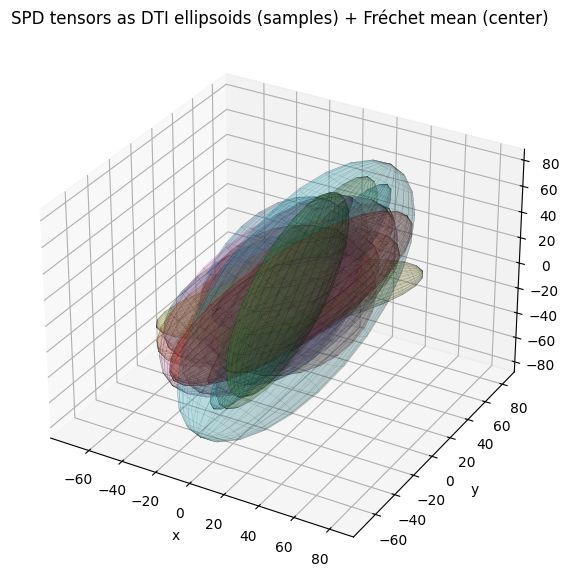

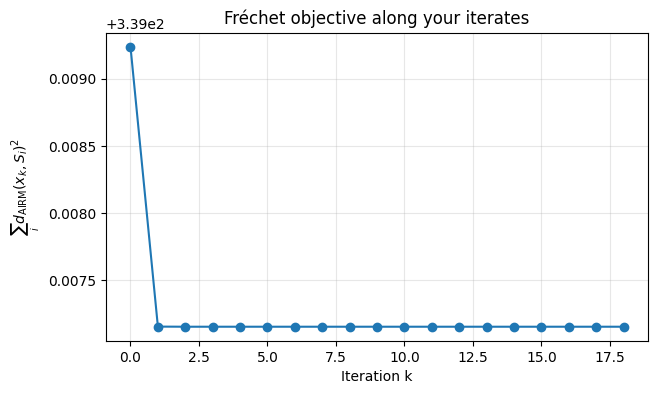

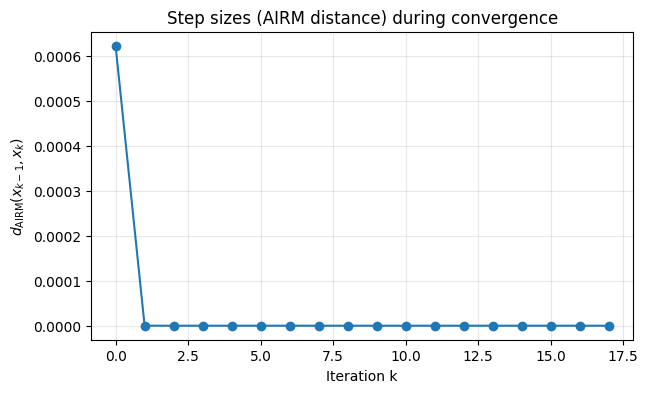

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def tensor_axes(D, scale=1.0):
    """Return eigenvectors (3x3) and axis lengths (3,) for ellipsoid of SPD D."""
    D = 0.5 * (D + D.T)
    w, V = np.linalg.eigh(D)
    w = np.maximum(w, 1e-30)
    # axis lengths proportional to sqrt(eigenvalues) (DTI convention)
    a = scale * np.sqrt(w)
    return V, a

def ellipsoid_mesh(a, n_u=30, n_v=15):
    """Parametric mesh for an axis-aligned ellipsoid with semi-axes a=(a1,a2,a3)."""
    u = np.linspace(0, 2*np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)
    x = a[0] * np.outer(np.cos(u), np.sin(v))
    y = a[1] * np.outer(np.sin(u), np.sin(v))
    z = a[2] * np.outer(np.ones_like(u), np.cos(v))
    return x, y, z

def plot_tensor_ellipsoid(ax, D, center=(0,0,0), scale=1.0, alpha=0.2, linewidth=0.5):
    """Plot SPD tensor D as a rotated ellipsoid surface in 3D."""
    V, a = tensor_axes(D, scale=scale)
    x, y, z = ellipsoid_mesh(a)
    # rotate points: [x;y;z] -> V @ [x;y;z]
    pts = np.stack([x, y, z], axis=0).reshape(3, -1)
    pts = V @ pts
    xR = pts[0].reshape(x.shape) + center[0]
    yR = pts[1].reshape(y.shape) + center[1]
    zR = pts[2].reshape(z.shape) + center[2]
    ax.plot_surface(xR, yR, zR, alpha=alpha, linewidth=linewidth, edgecolor="k")

def set_axes_equal(ax):
    """Make 3D axes have equal scale."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    r = 0.5 * max([x_range, y_range, z_range])
    x_mid = np.mean(x_limits)
    y_mid = np.mean(y_limits)
    z_mid = np.mean(z_limits)
    ax.set_xlim3d([x_mid - r, x_mid + r])
    ax.set_ylim3d([y_mid - r, y_mid + r])
    ax.set_zlim3d([z_mid - r, z_mid + r])

# ---------- your data + mean ----------
space = SymmetricPositiveDefinite(dimension=3, metric="AIRM")
prox = Prox(space=space)

S = space.sample(n_samples=20, dtype=np.float64)  # or your DTI-like synthetic list
S_list = list(S)

mu, traj = prox.Frechet_mean(
    x0=S_list[0], X=S_list, method="relaxed",
    tau=0.7, lam=1.0, tol=1e-14, max_iter=120, show_progress=False
)

# Extract iterates (your algorithm returns cycles; last element is new x_k)
x_path = [traj[0][0]]  # just something to start; we'll overwrite properly below
x_path = []
for k in range(1, len(traj)):
    x_path.append(traj[k][-1])  # x_k = last point of the k-th cycle

# ---------- Visualization 1: samples + mean as ellipsoids ----------
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Put each sample ellipsoid at a different center so they don't overlap
grid = int(np.ceil(np.sqrt(len(S_list))))
spacing = 3.0
centers = []
for i in range(len(S_list)):
    r = i // grid
    c = i % grid
    centers.append((spacing*c, spacing*r, 0.0))

# Choose a scale so ellipsoids are visible (your SPD entries are ~1e-3)
scale = 60.0

for X, ctr in zip(S_list, centers):
    plot_tensor_ellipsoid(ax, X, center=ctr, scale=scale, alpha=0.15, linewidth=0.2)

# Plot mean at the center of the grid, larger + less transparent
mean_center = (spacing*(grid-1)/2, spacing*(grid-1)/2, 0.0)
plot_tensor_ellipsoid(ax, mu, center=mean_center, scale=scale, alpha=0.55, linewidth=0.6)

ax.set_title("SPD tensors as DTI ellipsoids (samples) + Fréchet mean (center)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
set_axes_equal(ax)
plt.show()

# ---------- Visualization 2: convergence of the iterate (objective vs iteration) ----------
def objective(mu_, S_):
    return sum(space.dist(mu_, X)**2 for X in S_)

objs = [objective(xk, S_list) for xk in x_path]

plt.figure(figsize=(7, 4))
plt.plot(objs, marker="o")
plt.xlabel("Iteration k")
plt.ylabel(r"$\sum_i d_{\mathrm{AIRM}}(x_k, S_i)^2$")
plt.title("Fréchet objective along your iterates")
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Visualization 3: how far x_k moves each iteration ----------
steps = [space.dist(x_path[k-1], x_path[k]) for k in range(1, len(x_path))]

plt.figure(figsize=(7, 4))
plt.plot(steps, marker="o")
plt.xlabel("Iteration k")
plt.ylabel(r"$d_{\mathrm{AIRM}}(x_{k-1}, x_k)$")
plt.title("Step sizes (AIRM distance) during convergence")
plt.grid(True, alpha=0.3)
plt.show()